In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
# Load the data
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')

# Preview the data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Columns in train_df:**

* PassengerId: ID of the passenger (just an identifier)
* Survived: Target variable (0 = No, 1 = Yes)
* Pclass: Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)
* Name: Full name (can extract titles from here)
* Sex: Gender
* Age: Age in years
* SibSp: # of siblings/spouses aboard
* Parch: # of parents/children aboard
* Ticket: Ticket number
* Fare: Fare paid
* Cabin: Cabin number (many missing values)
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [3]:
# Basic info
train_df.info()

# Check missing values
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Handling Missing Values**

🔴 1. Age (177 missing)
Important feature — can't drop it.

🔴 2. Cabin (687 missing)
Too many missing — we won’t try to fill it fully.

🔴 3. Embarked (2 missing)
Only 2; easy fix!

In [4]:
# Fill Embarked with most common value
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
# train_df['Embarked'] accesses the Embarked column.
# .mode() calculates the most frequent value (e.g., 'S' for Southampton).
# mode()[0] gets the first (and most common) value.
# .fillna(...) fills missing values in the column with that common value.
# Finally, it assigns the result back to the Embarked column.




# Fill Age with median age grouped by Pclass and Sex
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
# train_df.groupby(['Pclass', 'Sex']) groups the dataset by passenger class and gender.
# ['Age'] selects the Age column within each group.
# .transform(...) allows to apply a function to each group while keeping the same shape as the original column.
# lambda x: x.fillna(x.median()) says: for each group, fill missing ages with the median age of that group.
# Finally, it assigns the result back to the Age column.




# Create HasCabin feature (1 if cabin info exists, 0 otherwise)
train_df['HasCabin'] = train_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
# train_df['Cabin'] accesses the Cabin column.
# .apply(lambda x: 0 if pd.isna(x) else 1):
# For each value x in the column:
# If it's missing (NaN), return 0
# If it's not missing, return 1
# This creates a new column HasCabin, where:
# 0 = No cabin info
# 1 = Cabin info present

Some visualization to understand the pattern

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')

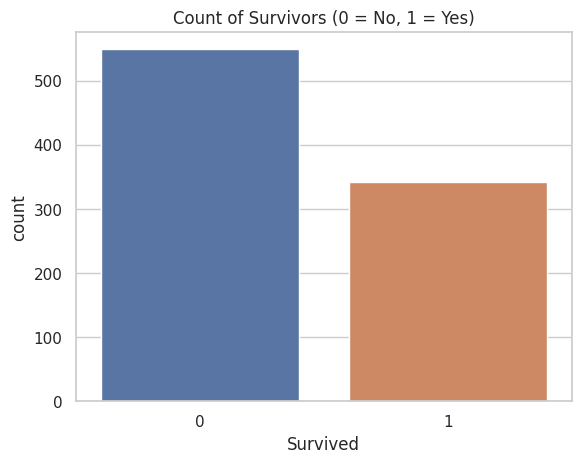

In [6]:
sns.countplot(data=train_df, x='Survived')
plt.title('Count of Survivors (0 = No, 1 = Yes)')
plt.show()
# This shows how many passengers survives vs didn't

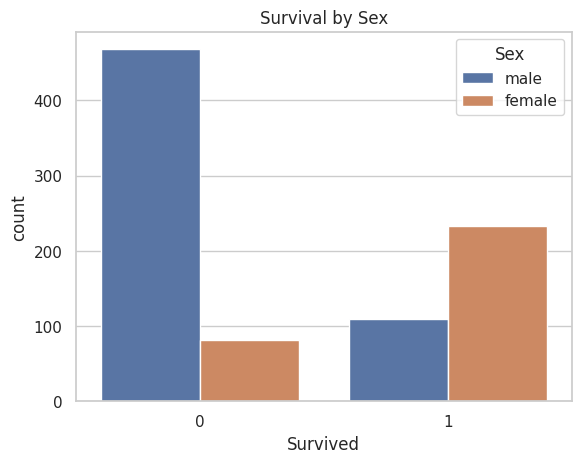

In [7]:
sns.countplot(data=train_df, x='Survived', hue='Sex')
plt.title('Survival by Sex')
plt.show()

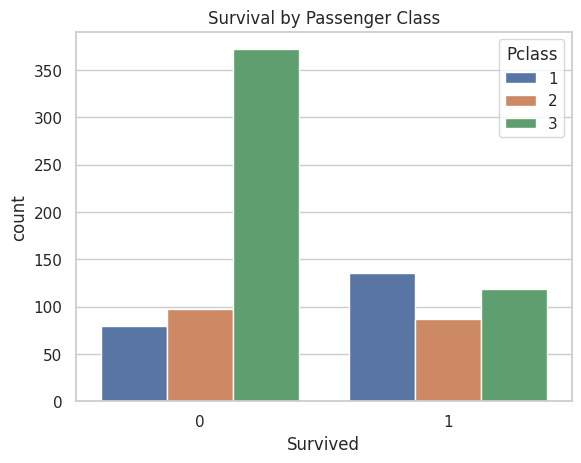

In [8]:
sns.countplot(data=train_df, x='Survived', hue='Pclass')
plt.title('Survival by Passenger Class')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


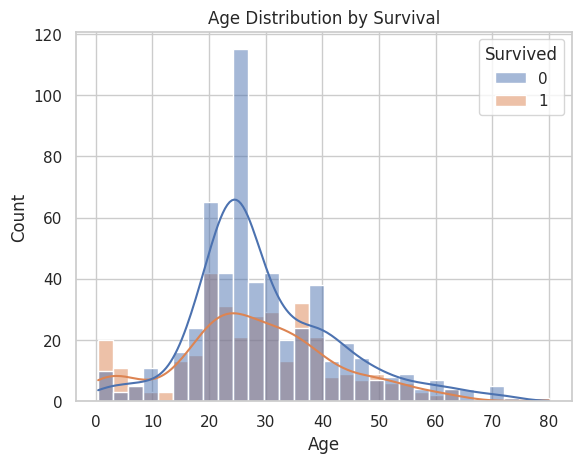

In [9]:
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.show()

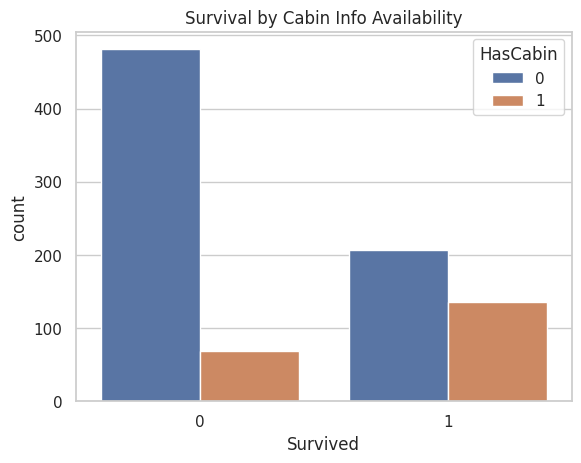

In [10]:
sns.countplot(data=train_df, x='Survived', hue='HasCabin')
plt.title('Survival by Cabin Info Availability')
plt.show()

**Feature Engineering**

We engineered three new columns using existing data to help the model learn better patterns:

In [11]:
# Extract title from Name
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Simplify titles
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace(['Mme'], 'Mrs')
train_df['Title'] = train_df['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Sir', 'Don', 'Jonkheer', 'Dona', 'Lady', 'Countess'], 'Rare')

# Create FamilySize
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# Create IsAlone: 1 if alone, 0 otherwise
train_df['IsAlone'] = 0
train_df.loc[train_df['FamilySize'] == 1, 'IsAlone'] = 1

# Preview new columns
train_df[['Name', 'Title', 'FamilySize', 'IsAlone']].head()

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


**Encoding categorical variables**

In [12]:
# Convert 'Sex' to numeric: male = 0, female = 1
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked and Title
train_df = pd.get_dummies(train_df, columns=['Embarked', 'Title'], drop_first=True)

In [13]:
# These are all either numerical or one-hot encoded, and have strong correlation with survival.
features = [
    'Pclass', 'Sex', 'Age', 'Fare',
    'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin',
    'Embarked_Q', 'Embarked_S',
    'Title_Miss', 'Title_Mr', 'Title_Rare'
]

In [14]:
#So our features and target :
X = train_df[features]
y = train_df['Survived']

In [15]:
# Spliting the training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

*Training time*

**Random Forest Classifier:** It’s great because it handles mixed feature types well and usually performs nicely out of the box



In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [17]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
# prediction on the test data
y_pred = model.predict(X_test)

* y_test is the actual true labels (ground truth) for the test set — what really happened (survived or not).
* y_pred is the predicted labels the model guessed for the test set, based on what it learned from the training data.

The evaluation compares these two to see how well the model is doing. For example, **accuracy_score(y_test, y_pred)** tells you the percentage of correct predictions.



In [19]:
# Evaluation
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8324


In [20]:
# Extract title from Name
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Simplify titles
test_df['Title'] = test_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
test_df['Title'] = test_df['Title'].replace(['Mme'], 'Mrs')
test_df['Title'] = test_df['Title'].replace(
    ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Sir', 'Don', 'Jonkheer', 'Dona', 'Lady', 'Countess'], 'Rare')

# Create FamilySize
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

# Create IsAlone: 1 if alone, 0 otherwise
test_df['IsAlone'] = 0
test_df.loc[test_df['FamilySize'] == 1, 'IsAlone'] = 1

# Map Sex to numeric: male = 0, female = 1
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

# Fill missing values in test_df (important!)
test_df['Age'] = test_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

# One-hot encode Embarked and Title, drop first to avoid dummy variable trap (same as train)
test_df = pd.get_dummies(test_df, columns=['Embarked', 'Title'], drop_first=True)

# After this, ensure test_df has all columns train_df used as features
# If any expected columns are missing (due to no occurrence in test), add them with default 0
expected_cols = [
    'FamilySize', 'IsAlone', 'HasCabin', 'Embarked_Q', 'Embarked_S',
    'Title_Miss', 'Title_Mr', 'Title_Rare'
]

# Create HasCabin column in test_df similar to train
test_df['HasCabin'] = test_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

#Adds the missing column named col to test_df
#Fills every row with 0 (which is the default value
#for a one-hot encoded feature that didn’t appear in the test data)
for col in expected_cols:
    if col not in test_df.columns:
        test_df[col] = 0


/tmp/ipykernel_35/157733693.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)
/tmp/ipykernel_35/157733693.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [21]:
# Select features from test set
X_test_final = test_df[features]

# Predict on the test set
test_predictions = model.predict(X_test_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")


Submission file created successfully!
